In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve


In [56]:
df = pd.read_csv(r"C:\Users\hp\Downloads\loan_dataset.csv")


In [57]:
df.isnull().sum()

Loan_ID               0
Gender               68
Married              68
Dependents           64
Education            68
Self_Employed        78
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            1
Loan_Amount_Term     62
Credit_History       64
Property_Area        56
dtype: int64

In [58]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())


In [59]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

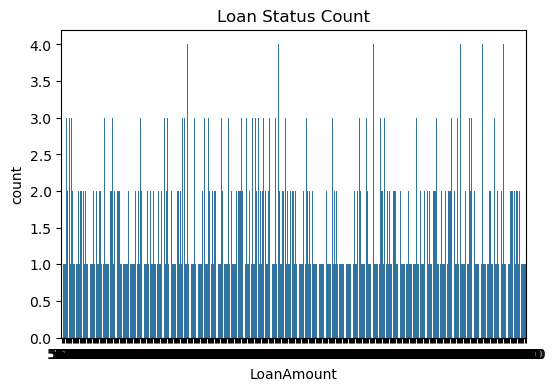

In [60]:
plt.figure(figsize=(6, 4))
sns.countplot(x='LoanAmount', data=df)
plt.title("Loan Status Count")
plt.show()


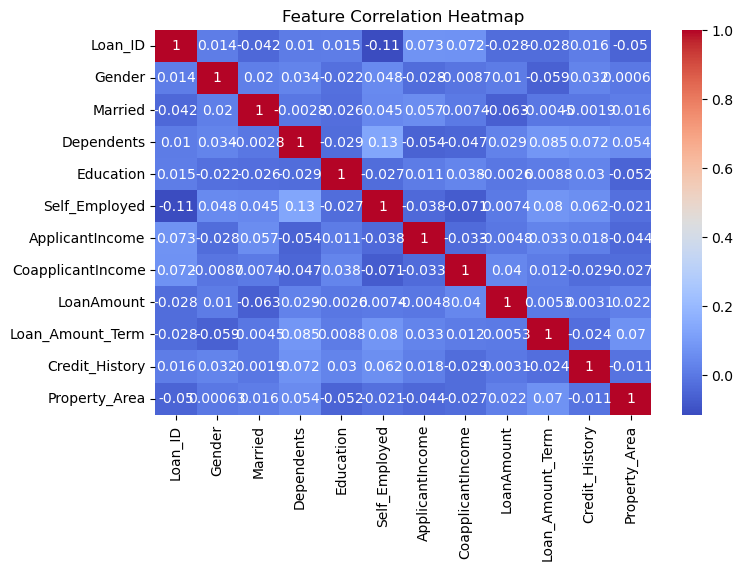

In [61]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [62]:
X = df.drop('Credit_History', axis=1)
y = df['Credit_History']



In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [65]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [66]:
results = {}

In [67]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n✅ {name} Results:")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))



✅ Logistic Regression Results:
Accuracy: 0.8416666666666667
Confusion Matrix:
 [[  0  19]
 [  0 101]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        19
         1.0       0.84      1.00      0.91       101

    accuracy                           0.84       120
   macro avg       0.42      0.50      0.46       120
weighted avg       0.71      0.84      0.77       120


✅ Decision Tree Results:
Accuracy: 0.6083333333333333
Confusion Matrix:
 [[ 4 15]
 [32 69]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.11      0.21      0.15        19
         1.0       0.82      0.68      0.75       101

    accuracy                           0.61       120
   macro avg       0.47      0.45      0.45       120
weighted avg       0.71      0.61      0.65       120



c:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



✅ Random Forest Results:
Accuracy: 0.8
Confusion Matrix:
 [[ 0 19]
 [ 5 96]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        19
         1.0       0.83      0.95      0.89       101

    accuracy                           0.80       120
   macro avg       0.42      0.48      0.44       120
weighted avg       0.70      0.80      0.75       120



C:\Users\hp\AppData\Local\Temp\ipykernel_5980\3382015643.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='Set2')


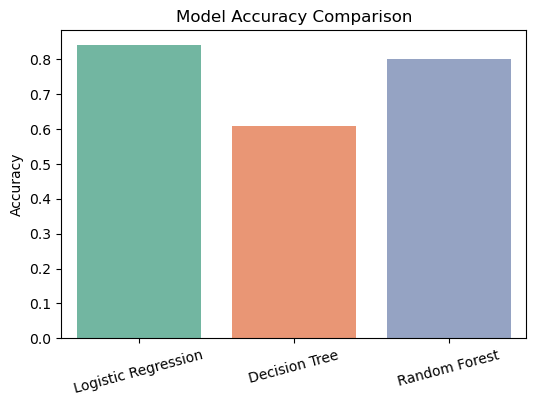

In [68]:
plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='Set2')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()


In [69]:

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_prob = best_model.predict_proba(X_test)[:, 1]


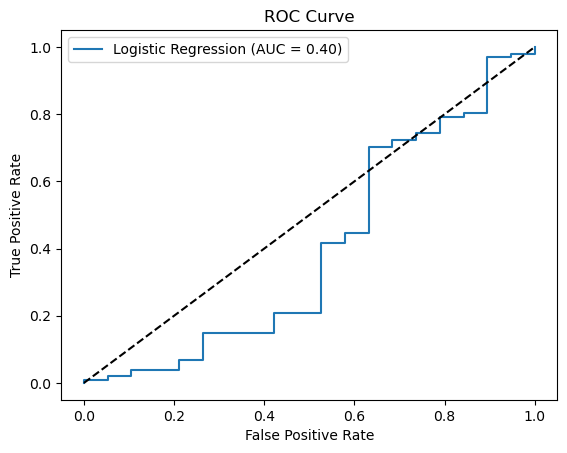

In [70]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()